In [1]:
import shutil
import pandas as pd
import random

import copy
import numpy as np # Import numpy for checking finite values
import matplotlib.pyplot as plt # Import matplotlib for potential debugging

import os
import math # Import math for ceil
from sklearn.manifold import TSNE # Import TSNE to check default perplexity

import os
import glob
import json
import numpy as np
import sys

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import numpy as np

In [2]:
import sys
fixed_path = 'C:\\Users\\Enrico Didoli\\0.Master_Thesis\\'
if fixed_path not in sys.path:
    sys.path.append(fixed_path)

cellcnn_path = f'{fixed_path}CellCNN/'
if cellcnn_path not in sys.path:
    sys.path.append(cellcnn_path)


old_cellcnn_path = f'{fixed_path}CellCNN/Old_CellCNN/'
if old_cellcnn_path not in sys.path:
    sys.path.append(old_cellcnn_path)

general_functions_path = f'{fixed_path}General_Functions/'
if general_functions_path not in sys.path:
    sys.path.append(general_functions_path)

save_path = f'{fixed_path}CellCNN/results/'
if save_path not in sys.path:
    sys.path.append(save_path)

In [3]:
decache_files = ['timepoints_elaboration', 'results_elaboration', 'new_datasets_generation', 'run_models',
                 'old_cellCnn.model', 'old_cellCnn.utils', 'old_cellCnn.downsample', 'old_cellCnn.model_grid' ]

# Rimuovi il modulo specifico dalla cache
from timepoints_elaboration import remove_from_cache
remove_from_cache(decache_files)


# import downloaded modules
from old_cellCnn.model import CellCnn

import old_cellCnn.utils as utils
import old_cellCnn.downsample as downsample

from timepoints_elaboration import load_data, donation_extraction, dataset_elaboration
from timepoints_elaboration import donor_division, patient_code_extraction, remove_from_cache

from results_elaboration import extract_hyper, phenotype_prediction, default_serializer, show_hyperparameters
from results_elaboration import elaborate_predictions, show_hyper

from run_models import trials_train_CellCNN, trials_test_CellCNN, trials_train_CellCNN_old, trials_test_CellCNN_old

from new_datasets_generation import splitting_and_dataset_elaboration

timepoints_elaboration rimosso dalla cache
results_elaboration non trovato nella cache
new_datasets_generation non trovato nella cache
run_models non trovato nella cache
old_cellCnn.model non trovato nella cache
old_cellCnn.utils non trovato nella cache
old_cellCnn.downsample non trovato nella cache
old_cellCnn.model_grid non trovato nella cache


In [4]:
%%time

# Trova tutti i file con estensione specifica in una cartella
data_folder = f'{fixed_path}B-ALL_Datasets'
extension = '*.csv'  # cambia con l'estensione che ti serve

multiple_donations, ALL_DATASETS = load_data(data_path = data_folder, ext = extension)

Elaborating file 0: C:\Users\Enrico Didoli\0.Master_Thesis\B-ALL_Datasets\B-ALL_expression_matrix_220204-2900.csv
Elaborating file 1: C:\Users\Enrico Didoli\0.Master_Thesis\B-ALL_Datasets\B-ALL_expression_matrix_220208-3665.csv
Elaborating file 2: C:\Users\Enrico Didoli\0.Master_Thesis\B-ALL_Datasets\B-ALL_expression_matrix_220216-3546.csv
Elaborating file 3: C:\Users\Enrico Didoli\0.Master_Thesis\B-ALL_Datasets\B-ALL_expression_matrix_B-ALL_GHE11_D15_1.csv
Elaborating file 4: C:\Users\Enrico Didoli\0.Master_Thesis\B-ALL_Datasets\B-ALL_expression_matrix_B-ALL_GHE11_D29_1.csv
Elaborating file 5: C:\Users\Enrico Didoli\0.Master_Thesis\B-ALL_Datasets\B-ALL_expression_matrix_B-ALL_GHE11_D71_1.csv
Elaborating file 6: C:\Users\Enrico Didoli\0.Master_Thesis\B-ALL_Datasets\B-ALL_expression_matrix_B-ALL_GHE12_D15_2.csv
Elaborating file 7: C:\Users\Enrico Didoli\0.Master_Thesis\B-ALL_Datasets\B-ALL_expression_matrix_B-ALL_GHE12_D29_1.csv
Elaborating file 8: C:\Users\Enrico Didoli\0.Master_Thesis

In [5]:
print(multiple_donations)

{'11': [3, 4, 5], '12': [6, 7], '1': [8, 9], '2': [10, 11], '3': [12, 13], '4': [14, 15, 16], '6': [17, 18], '7': [19, 20, 21], '8': [22, 23], '9': [24, 25], '13': [0], '14': [1], '15': [2]}


In [6]:
healthy_donors, blast_donors, mixed_donors = donor_division(multiple_donations, ALL_DATASETS)

print(healthy_donors, blast_donors, mixed_donors)

# Samples donors for Train, Validation and Test sets    
seed = 105619

train_donors_idx, val_donors_idx, test_donors_idx = dataset_elaboration(multiple_donations, ALL_DATASETS, healthy_donors, blast_donors,
                        mixed_donors, seed = seed)



{'11': [1, 1, 0], '12': [1, 1], '1': [1, 0], '2': [1, 1], '3': [1, 0], '4': [1, 1, 0], '6': [1, 1], '7': [1, 1, 0], '8': [1, 1], '9': [1, 1], '13': [0], '14': [0], '15': [0]}
['13', '14', '15'] ['12', '2', '6', '8', '9'] ['11', '1', '3', '4', '7']
Precess starts. Dividing donors...
healthy_donors_idx, blast_donors_idx, mixed_donors_idx: [0, 2, 1], [0, 4, 2, 1, 3],[4, 0, 2, 1, 3]
Seting Train, Validation and Test idx...
['12', '9', '13', '7'] ['6', '15', '3'] ['2', '8', '14', '11', '1', '4']


In [7]:
def CV_train_val_splits(healthy_donors, blast_donors, mixed_donors,  test_donors_idx):
    h_pat, b_pat, m_pat = healthy_donors.copy(), blast_donors.copy(), mixed_donors.copy()
    
    for pat in test_donors_idx:
        if pat in healthy_donors:
            h_pat.remove(pat)
        if pat in blast_donors:
             b_pat.remove(pat)
        if pat in mixed_donors:
            m_pat.remove(pat)
    
    #print(h_pat, b_pat, m_pat)
    
    train_perm = []
    for hp in h_pat:
        for mp in m_pat:
            train_perm.append([hp, mp, b_pat[0], b_pat[1]])
            train_perm.append([hp, mp, b_pat[0], b_pat[2]])
            train_perm.append([hp, mp, b_pat[1], b_pat[2]])
    
    tot_train_val_perm = h_pat + b_pat + m_pat
    val_perm = []
    for element in train_perm:
        q = set(tot_train_val_perm.copy()) - set(element)
        val_perm.append(list(q))
    
    for t_fold, v_fold in zip(train_perm, val_perm):
        print(t_fold, v_fold)
    return train_perm, val_perm

def choose_folds(iterations, train_perm, val_perm, seed = 42):
    print(seed)
    np.random.seed(seed)
    tot_perm = len(train_perm)
    
    idx = np.arange(tot_perm)
    np.random.shuffle(idx)

    chosen_folds = []
    for index in idx[:iterations]:
        chosen_folds.append([train_perm[index], val_perm[index]])
    
    return chosen_folds
    
train_perm, val_perm = CV_train_val_splits(healthy_donors, blast_donors, mixed_donors,  test_donors_idx)

iterations = 12
chosen_perm = choose_folds(iterations, train_perm, val_perm, seed)

['13', '3', '12', '6'] ['7', '9', '15']
['13', '3', '12', '9'] ['7', '15', '6']
['13', '3', '6', '9'] ['12', '7', '15']
['13', '7', '12', '6'] ['15', '9', '3']
['13', '7', '12', '9'] ['6', '15', '3']
['13', '7', '6', '9'] ['12', '15', '3']
['15', '3', '12', '6'] ['7', '13', '9']
['15', '3', '12', '9'] ['7', '13', '6']
['15', '3', '6', '9'] ['12', '7', '13']
['15', '7', '12', '6'] ['13', '9', '3']
['15', '7', '12', '9'] ['6', '13', '3']
['15', '7', '6', '9'] ['12', '13', '3']
105619


In [9]:
print(chosen_perm)

[[['13', '3', '12', '9'], ['7', '15', '6']], [['13', '7', '12', '6'], ['15', '9', '3']], [['13', '7', '12', '9'], ['6', '15', '3']], [['15', '3', '12', '9'], ['7', '13', '6']], [['15', '3', '12', '6'], ['7', '13', '9']], [['13', '3', '6', '9'], ['12', '7', '15']], [['15', '7', '12', '6'], ['13', '9', '3']], [['13', '3', '12', '6'], ['7', '9', '15']], [['15', '7', '12', '9'], ['6', '13', '3']], [['15', '3', '6', '9'], ['12', '7', '13']], [['15', '7', '6', '9'], ['12', '13', '3']], [['13', '7', '6', '9'], ['12', '15', '3']]]


[[['13', '12', '3', '15'], [0.0, 0.15, 0.0, 0.03, 0.0, 0.0], 0.03, 0.05477225575051661], [['6', '7', '9'], [1.44, 0.01, 0.31, 0.21, 0.0, 27.79, 0.28], 4.291428571428571, 9.60403104143765]]
[0.5, 0.5, 0.5740740740740741, 0.5185185185185185, 0.5185185185185185, 0.5, 0.5]
[0.0, 0.0, 0.2545454545454546, 0.06666666666666667, 0.06666666666666667, 0.0, 0.0]


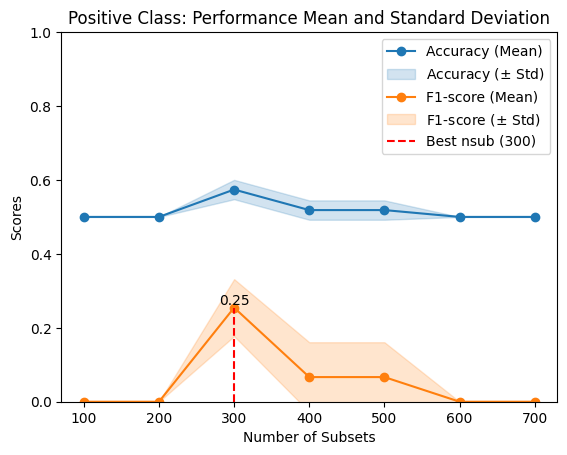

[[['3', '15', '6', '7', '9'], [0.03, 0.0, 0.0, 1.44, 0.01, 0.31, 0.21, 0.0, 27.79, 0.28], 3.007, 8.27137721301598], [['13', '12'], [0.0, 0.15, 0.0], 0.049999999999999996, 0.07071067811865475]]
[1.0, 0.9259259259259259, 0.9259259259259259, 1.0, 1.0, 0.9259259259259259, 0.9259259259259259]
[1.0, 0.9166666666666666, 0.9166666666666666, 1.0, 1.0, 0.9166666666666666, 0.9166666666666666]


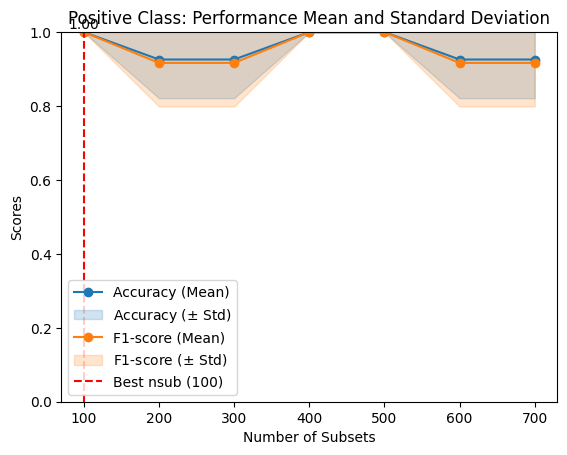

[[['13', '12', '6', '7', '9'], [0.0, 0.15, 0.0, 1.44, 0.01, 0.31, 0.21, 0.0, 27.79, 0.28], 3.019, 8.267135477298046], [['3', '15'], [0.03, 0.0, 0.0], 0.01, 0.01414213562373095]]
[0.9259259259259259, 0.9629629629629629, 0.8518518518518517, 1.0, 1.0, 0.7777777777777777, 0.8518518518518517]
[0.8666666666666667, 0.9523809523809524, 0.8412698412698413, 1.0, 1.0, 0.7777777777777777, 0.8222222222222223]


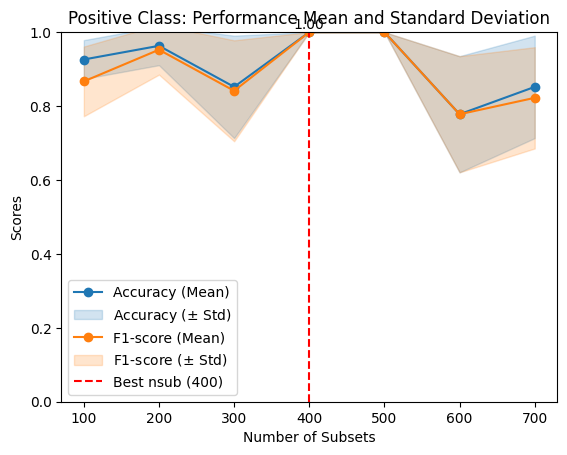

In [11]:
def plot_nsub_step_2(acc_5_means, f1_5_means, n_sub_step2_x_axis):
    
    
    acc_ncells_5_means = [np.mean(acc) for acc in acc_5_means]
    print(acc_ncells_5_means)
    f1_ncells_5_means = [np.mean(f1) for f1 in f1_5_means]
    print(f1_ncells_5_means)
    
    acc_ncells_5_stds = [np.std(acc) for acc in acc_5_means]

    f1_ncells_5_stds = [np.std(f1) for f1 in f1_5_means]
    
    max_idx = f1_ncells_5_means.index(np.max(f1_ncells_5_means))
    # Plot Accuracy Mean
    plt.plot(n_sub_step2_x_axis, acc_ncells_5_means, marker='o', label='Accuracy (Mean)', color='C0')
    # Plot Accuracy Std as a shaded region
    acc_upper = np.array(acc_ncells_5_means) + np.array(acc_ncells_5_stds)
    acc_lower = np.array(acc_ncells_5_means) - np.array(acc_ncells_5_stds)
    plt.fill_between(n_sub_step2_x_axis, acc_lower, acc_upper, color='C0', alpha=0.2, label='Accuracy ($\pm$ Std)')
    
    # Plot F1-score Mean
    plt.plot(n_sub_step2_x_axis, f1_ncells_5_means, marker='o', label='F1-score (Mean)', color='C1')
    # Plot F1-score Std as a shaded region
    f1_upper = np.array(f1_ncells_5_means) + np.array(f1_ncells_5_stds)
    f1_lower = np.array(f1_ncells_5_means) - np.array(f1_ncells_5_stds)
    plt.fill_between(n_sub_step2_x_axis, f1_lower, f1_upper, color='C1', alpha=0.2, label='F1-score ($\pm$ Std)')

    y = f1_ncells_5_means[max_idx]
    plt.text(n_sub_step2_x_axis[max_idx], y, f"{y:.2f}", ha='center', va='bottom')
    
    plt.vlines(x = n_sub_step2_x_axis[max_idx], ymin = 0, ymax = np.max(f1_ncells_5_means), color='red', linestyle='--', label=f'Best nsub ({n_sub_step2_x_axis[max_idx]})')
    plt.ylim(0,1)
    plt.title('Positive Class: Performance Mean and Standard Deviation')
    plt.xlabel("Number of Subsets")
    plt.ylabel("Scores")
    plt.legend()
    plt.show()

tuning_ncell_test_path = f'{fixed_path}CellCNN\\results\\old\\n_sub_tuning\\/folder_testing/'
#tuning_ncell_test_path = 'C:\\Users\\Enrico Didoli\\0.Master_Thesis/CellCNN/New running ipynb/computer_piccolo/results/folder_testing/'
mod = 4
with open(f'{tuning_ncell_test_path}tuning_ncell_test_acc_{mod}.json', 'r', encoding = "utf-8") as f:
    acc_imported = json.load(f)
with open(f'{tuning_ncell_test_path}tuning_ncell_test_f1_{mod}.json', 'r', encoding = "utf-8") as f:
    f1_imported = json.load(f)
with open(f'{tuning_ncell_test_path}tested_folds_{mod}.json', 'r', encoding = "utf-8") as f:
    tested_folds = json.load(f)
    
for acc_fold_im, f1_fold_im, fold in zip(acc_imported, f1_imported, tested_folds):
    print(fold)
    n_cells_list = list(range(100, 800, 100))
    plot_nsub_step_2(acc_fold_im, f1_fold_im, n_cells_list)


In [12]:
import re
import ast
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

train_heat, val_heat = [], []
train_labels, val_labels = [], []
for train_f, val_f in tested_folds:

    train_heat.append(train_f[1])
    train_labels.append(train_f[0])
    val_heat.append(val_f[1])
    val_labels.append(val_f[0])
    
print(train_heat)
print(val_heat)
print(train_labels)
print(val_labels)

train_heat, val_heat = [], []
train_labels, val_labels = [], []
for train_f, val_f in chosen_perm:
    print(train_f, val_f)
    train_heat.append(train_f[1])
    train_labels.append(train_f[0])
    val_heat.append(val_f[1])
    val_labels.append(val_f[0])

def heatmap_fold(train_heat, train_labels, multiple_donations, fold = 'train'):
    if fold == 'train':
        fold_text = 'Training'
    elif fold == 'valid':
        fold_text = 'Validation'
        
    patient_labels = []
    for fold in train_labels:
        labels = []
        
        for idx in fold:
             labels += [int(idx)]*len(multiple_donations[idx])
    
        patient_labels.append(labels)
    
    
    # Convert the list of lists into a DataFrame
    train_heat_df = pd.DataFrame(train_heat)
    train_labels_df = pd.DataFrame(patient_labels)
    
    train_heat_df.index = [f'Combination {i+1}' for i in range(len(train_heat_df))]
    train_labels_df.index = [f'Combination {i+1}' for i in range(len(train_labels_df))]

    
    plt.figure(figsize=(12, 6))
    ax = sns.heatmap(
        train_heat_df,
        annot=train_labels_df, # Annotation is now set to True
        #annot = True,
        #mt=".2f",  # Format the percentage values to 2 decimal places
        cmap='viridis',
        cbar_kws={'label': 'Percentage Value'},
        linewidths=.5,
        linecolor='black'
    )

    if fold == 'train':
        fold_text = 'Training'
    elif fold == 'valid':
        fold_text = 'Validation'
    plt.title(f'Heatmap of {fold_text} Percentage Combinations')
    plt.ylabel('Patient ID/Combination')
    plt.xlabel('Combined Feature Index')
    
    # Add custom text labels for the sections
    #plt.text(split_point / 2, -0.5, f'{fold_text} Set Features', 
    #         ha='center', va='center', fontsize=12, color='darkred', weight='bold', transform=ax.transData)
    
    plt.tight_layout()
    plt.savefig(f'heatmap_{fold_text}_validation.png')
    
    #print(f"The split point (index where the line is drawn) is: {split_point}")

heatmap_fold(train_heat, train_labels, multiple_donations)
heatmap_fold(val_heat, val_labels, multiple_donations, 'valid')

[[0.0, 0.15, 0.0, 0.03, 0.0, 0.0], [0.03, 0.0, 0.0, 1.44, 0.01, 0.31, 0.21, 0.0, 27.79, 0.28], [0.0, 0.15, 0.0, 1.44, 0.01, 0.31, 0.21, 0.0, 27.79, 0.28]]
[[1.44, 0.01, 0.31, 0.21, 0.0, 27.79, 0.28], [0.0, 0.15, 0.0], [0.03, 0.0, 0.0]]
[['13', '12', '3', '15'], ['3', '15', '6', '7', '9'], ['13', '12', '6', '7', '9']]
[['6', '7', '9'], ['13', '12'], ['3', '15']]
['13', '3', '12', '9'] ['7', '15', '6']
['13', '7', '12', '6'] ['15', '9', '3']
['13', '7', '12', '9'] ['6', '15', '3']
['15', '3', '12', '9'] ['7', '13', '6']
['15', '3', '12', '6'] ['7', '13', '9']
['13', '3', '6', '9'] ['12', '7', '15']
['15', '7', '12', '6'] ['13', '9', '3']
['13', '3', '12', '6'] ['7', '9', '15']
['15', '7', '12', '9'] ['6', '13', '3']
['15', '3', '6', '9'] ['12', '7', '13']
['15', '7', '6', '9'] ['12', '13', '3']
['13', '7', '6', '9'] ['12', '15', '3']


KeyError: '5'

[['13', '3', '12', '9'], [0.0, 0.03, 0.0, 0.15, 0.0, 27.79, 0.28], 4.035714285714286, 9.698136576746302] [['15', '6', '7'], [0.0, 1.44, 0.01, 0.31, 0.21, 0.0], 0.3283333333333333, 0.5110582702153987]
[['13', '7', '12', '6'], [0.0, 0.31, 0.21, 0.0, 0.15, 0.0, 1.44, 0.01], 0.265, 0.4575204913443768] [['15', '9', '3'], [0.0, 27.79, 0.28, 0.03, 0.0], 5.62, 11.085498635604985]
[['13', '7', '12', '9'], [0.0, 0.31, 0.21, 0.0, 0.15, 0.0, 27.79, 0.28], 3.5925, 9.146561854052045] [['15', '6', '3'], [0.0, 1.44, 0.01, 0.03, 0.0], 0.296, 0.5721048854886662]
[['15', '3', '12', '6'], [0.0, 0.03, 0.0, 0.15, 0.0, 1.44, 0.01], 0.23285714285714285, 0.4953415642827911] [['9', '7', '13'], [27.79, 0.28, 0.31, 0.21, 0.0, 0.0], 4.765, 10.297826226927702]


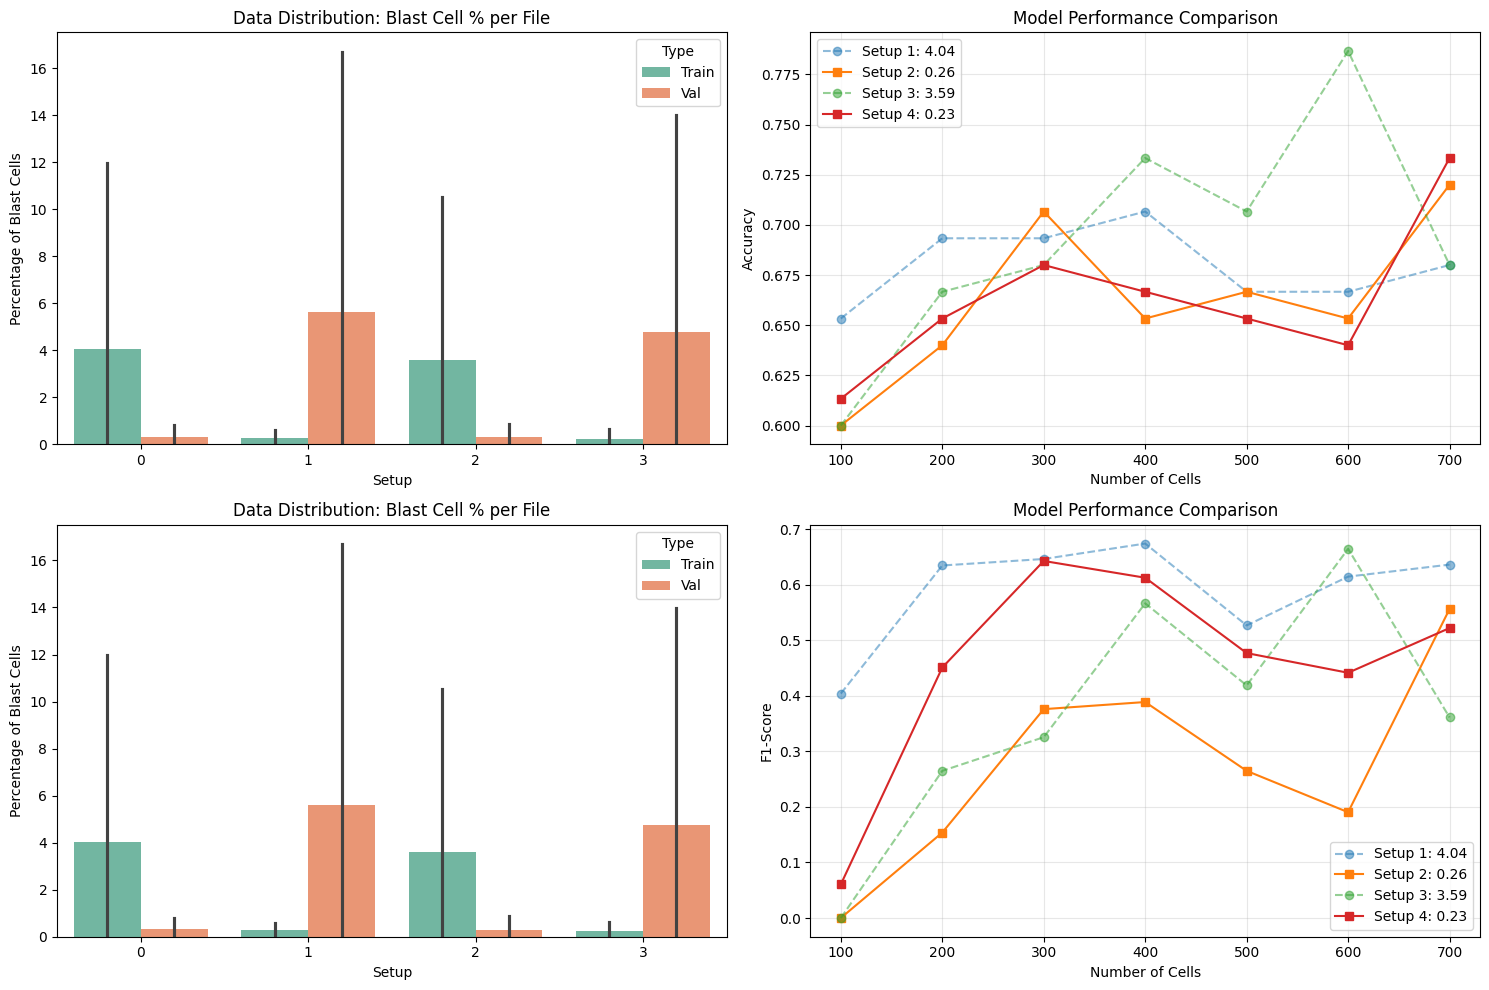

In [11]:
setup_counter = 0
all_setups = {}
for train_fold, val_fold in tested_folds:
    train_set = [train_fold[0], train_fold[1]]
    val_set = [val_fold[0], val_fold[1]]
    setup = [train_set, val_set]
    all_setups[setup_counter] = setup
    setup_counter += 1
    print(train_fold, val_fold)
#print(all_setups)


# 2. CREATE A DATAFRAME FOR DISTRIBUTION PLOTTING
rows = []
for setup_name, data in all_setups.items():
    # Process Train (Index 0)
    for val in data[0][1]: # The list of percentages
        rows.append({'Setup': setup_name, 'Type': 'Train', 'Blast %': val})
    # Process Val (Index 1)
    for val in data[1][1]:
        rows.append({'Setup': setup_name, 'Type': 'Val', 'Blast %': val})

df = pd.DataFrame(rows)

# 3. PLOT
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Plot A: Blast Cell Distribution Comparison
sns.barplot(data=df, x='Setup', y='Blast %', hue='Type', ax=axes[0][0], palette="Set2")
axes[0][0].set_title("Data Distribution: Blast Cell % per File")
axes[0][0].set_ylabel("Percentage of Blast Cells")

# Plot B: Performance Comparison (Mocking the line data based on your image)
# You would replace this with your actual 'Scores' lists
x_axis = [100, 200, 300, 400, 500, 600, 700]

y_acc_1 = [np.mean(acc) for acc in acc_imported[0]]
y_acc_2 = [np.mean(acc) for acc in acc_imported[1]]
y_acc_3 = [np.mean(acc) for acc in acc_imported[2]]
y_acc_4 = [np.mean(acc) for acc in acc_imported[3]]

# Plotting Accuracy Only for clarity (or use subplots for Acc vs F1)
axes[0][1].plot(x_axis, y_acc_1, marker='o', linestyle='--', label=f'Setup 1: {round(np.mean(all_setups[0][0][1]),2)}', color='tab:blue', alpha=0.5)
axes[0][1].plot(x_axis, y_acc_2, marker='s', label=f'Setup 2: {round(np.mean(all_setups[1][0][1]),2)}', color='tab:orange')
axes[0][1].plot(x_axis, y_acc_3, marker='o',linestyle='--', label=f'Setup 3: {round(np.mean(all_setups[2][0][1]),2)}', color='tab:green', alpha=0.5)
axes[0][1].plot(x_axis, y_acc_4, marker='s', label=f'Setup 4: {round(np.mean(all_setups[3][0][1]),2)}', color='tab:red')

axes[0][1].set_title("Model Performance Comparison")
axes[0][1].set_xlabel("Number of Cells")
axes[0][1].set_ylabel("Accuracy")
axes[0][1].legend()
axes[0][1].grid(True, alpha=0.3)


# Plot A: Blast Cell Distribution Comparison
sns.barplot(data=df, x='Setup', y='Blast %', hue='Type', ax=axes[1][0], palette="Set2")
axes[1][0].set_title("Data Distribution: Blast Cell % per File")
axes[1][0].set_ylabel("Percentage of Blast Cells")


y_f1_1 = [np.mean(f1) for f1 in f1_imported[0]]
y_f1_2 = [np.mean(f1) for f1 in f1_imported[1]]
y_f1_3 = [np.mean(f1) for f1 in f1_imported[2]]
y_f1_4 = [np.mean(f1) for f1 in f1_imported[3]]

# Plotting Accuracy Only for clarity (or use subplots for Acc vs F1)
axes[1][1].plot(x_axis, y_f1_1, marker='o', linestyle='--', label=f'Setup 1: {round(np.mean(all_setups[0][0][1]),2)}', color='tab:blue', alpha=0.5)
axes[1][1].plot(x_axis, y_f1_2, marker='s',  label=f'Setup 2: {round(np.mean(all_setups[1][0][1]),2)}', color='tab:orange')
axes[1][1].plot(x_axis, y_f1_3, marker='o', linestyle='--', label=f'Setup 3: {round(np.mean(all_setups[2][0][1]),2)}', color='tab:green', alpha=0.5)
axes[1][1].plot(x_axis, y_f1_4, marker='s', label=f'Setup 4: {round(np.mean(all_setups[3][0][1]),2)}', color='tab:red')

axes[1][1].set_title("Model Performance Comparison")
axes[1][1].set_xlabel("Number of Cells")
axes[1][1].set_ylabel("F1-Score")
axes[1][1].legend()#loc = 'upper left')
axes[1][1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

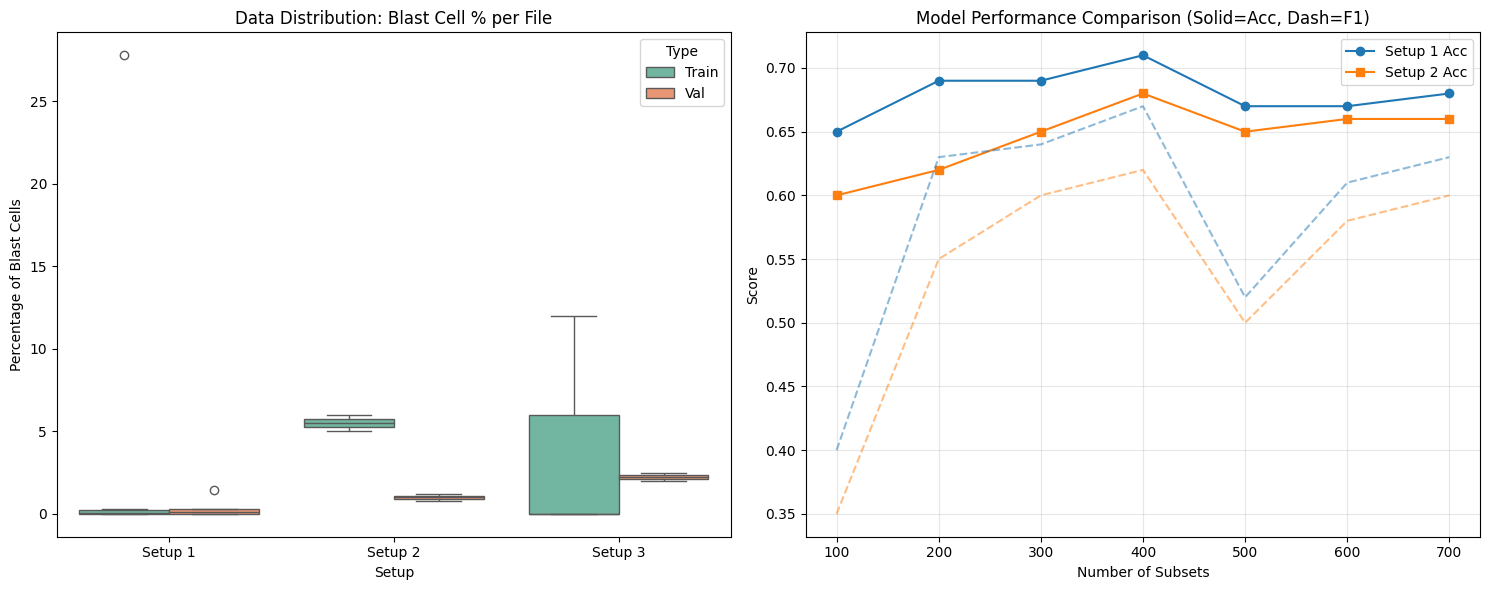

In [12]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import numpy as np
# 1. ORGANIZE YOUR INPUT DATA
# This is the format you provided. I am duplicating it to simulate 3 setups.
# [Patients, Percentages, Mean, Std]

data_setup_1 = [
    [['13', '3', '12', '9'], [0.0, 0.03, 0.0, 0.15, 0.0, 27.79, 0.28], 4.04, 9.70], # Train
    [['15', '6', '7'], [0.0, 1.44, 0.01, 0.31, 0.21, 0.0], 0.33, 0.51]             # Val
]

# (Mocking Setup 2 and 3 for the demo)
data_setup_2 = [
    [['1, 2'], [5.0, 6.0, 5.5], 5.5, 0.5], 
    [['3, 4'], [1.0, 1.2, 0.8], 1.0, 0.2]
]
data_setup_3 = [
    [['5, 6'], [12.0, 0.0, 0.0], 4.0, 6.0], 
    [['7, 8'], [2.0, 2.5], 2.25, 0.25]
]

all_setups = {'Setup 1': data_setup_1, 'Setup 2': data_setup_2, 'Setup 3': data_setup_3}

# 2. CREATE A DATAFRAME FOR DISTRIBUTION PLOTTING
rows = []
for setup_name, data in all_setups.items():
    # Process Train (Index 0)
    for val in data[0][1]: # The list of percentages
        rows.append({'Setup': setup_name, 'Type': 'Train', 'Blast %': val})
    # Process Val (Index 1)
    for val in data[1][1]:
        rows.append({'Setup': setup_name, 'Type': 'Val', 'Blast %': val})

df = pd.DataFrame(rows)

# 3. PLOT
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Plot A: Blast Cell Distribution Comparison
sns.boxplot(data=df, x='Setup', y='Blast %', hue='Type', ax=axes[0], palette="Set2")
axes[0].set_title("Data Distribution: Blast Cell % per File")
axes[0].set_ylabel("Percentage of Blast Cells")

# Plot B: Performance Comparison (Mocking the line data based on your image)
# You would replace this with your actual 'Scores' lists
x_axis = [100, 200, 300, 400, 500, 600, 700]

# Setup 1 (From your image approx)
y_acc_1 = [0.65, 0.69, 0.69, 0.71, 0.67, 0.67, 0.68]
y_f1_1 =  [0.40, 0.63, 0.64, 0.67, 0.52, 0.61, 0.63]

# Setup 2 (Mock - usually higher or lower)
y_acc_2 = [0.60, 0.62, 0.65, 0.68, 0.65, 0.66, 0.66]
y_f1_2 =  [0.35, 0.55, 0.60, 0.62, 0.50, 0.58, 0.60]

# Plotting Accuracy Only for clarity (or use subplots for Acc vs F1)
axes[1].plot(x_axis, y_acc_1, marker='o', label='Setup 1 Acc', color='tab:blue')
axes[1].plot(x_axis, y_acc_2, marker='s', label='Setup 2 Acc', color='tab:orange')
# Add F1 as dashed lines if desired
axes[1].plot(x_axis, y_f1_1, linestyle='--', color='tab:blue', alpha=0.5)
axes[1].plot(x_axis, y_f1_2, linestyle='--', color='tab:orange', alpha=0.5)

axes[1].set_title("Model Performance Comparison (Solid=Acc, Dash=F1)")
axes[1].set_xlabel("Number of Subsets")
axes[1].set_ylabel("Score")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()